--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null 

/tmp/ipython-input-688/558688905.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


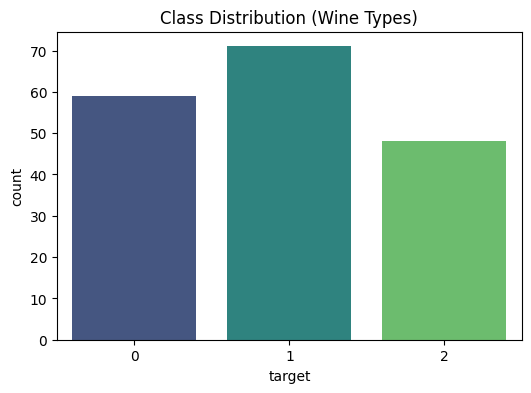

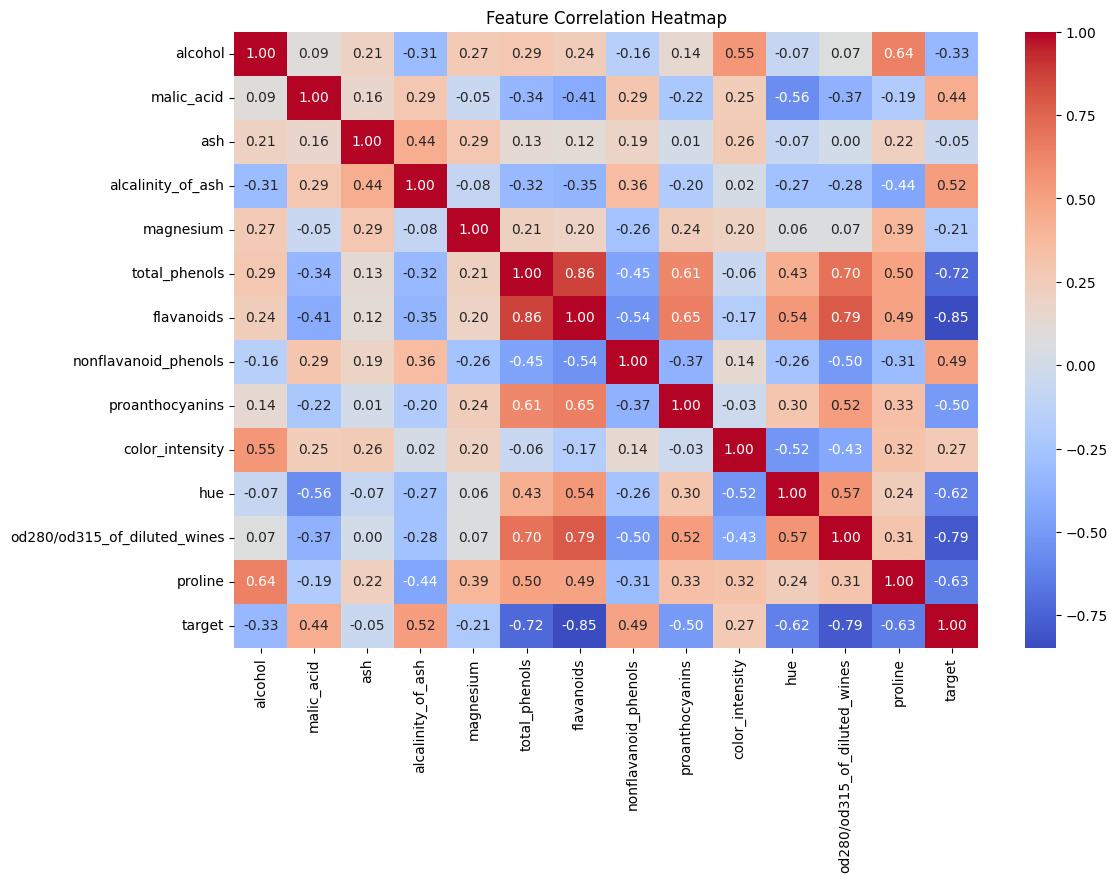

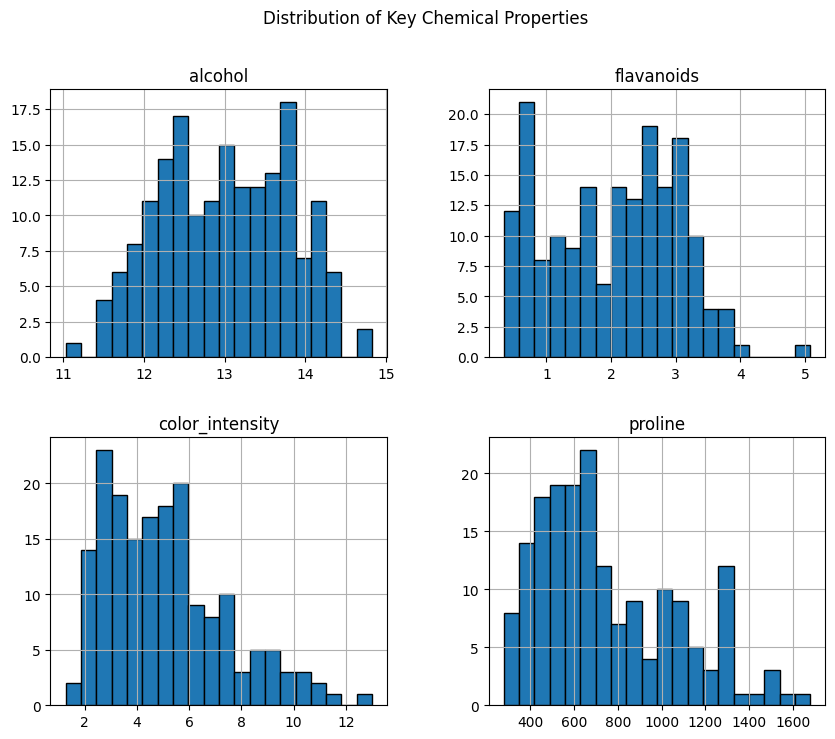

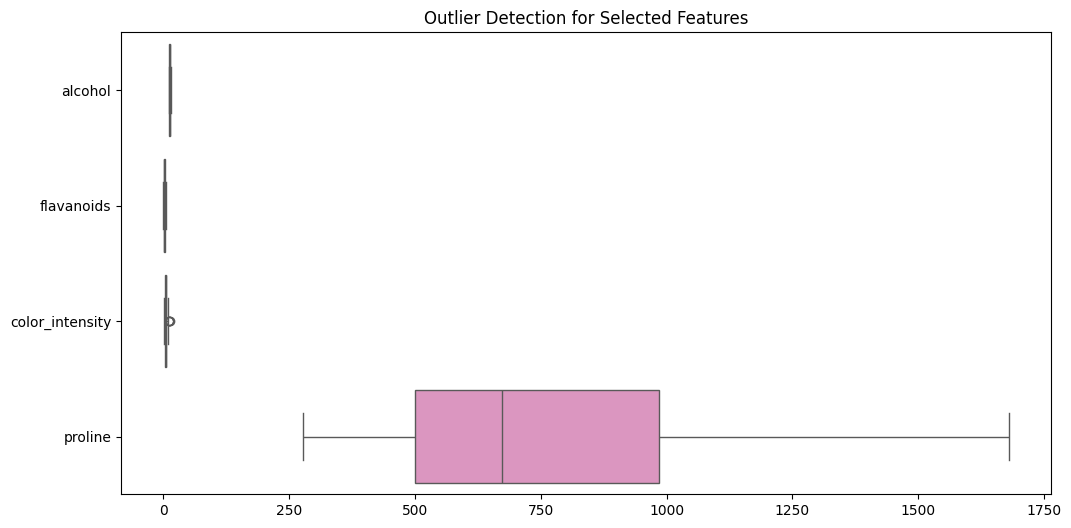

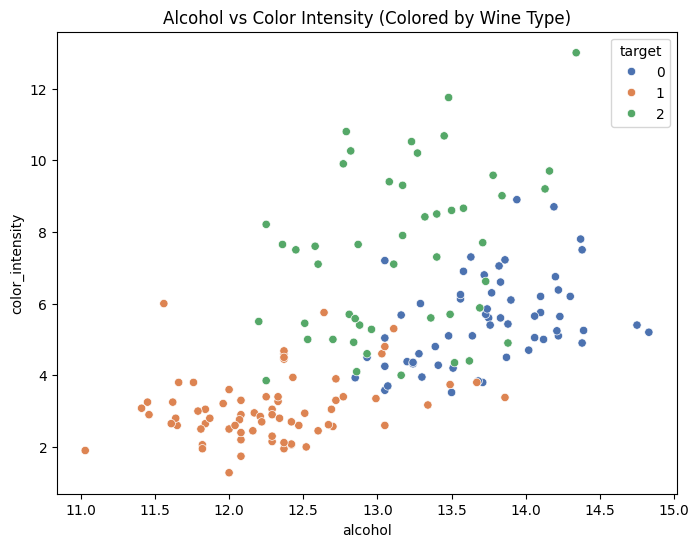

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# 1. Load and Prepare Data
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 2. Basic Inspection
print("--- Dataset Info ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Check for Missing Values & Class Balance
print("\n--- Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title("Class Distribution (Wine Types)")
plt.show()

# 4. Correlation Heatmap
# Highly correlated features might be redundant for a Decision Tree.
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

# 5. Distribution of Key Features
# Decision trees handle non-normal distributions well, but skewness is good to note.
cols_to_plot = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
df[cols_to_plot].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Distribution of Key Chemical Properties")
plt.show()

# 6. Outlier Detection with Boxplots
# Decision trees are robust to outliers, but extreme values can still affect splitting.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_plot], orient='h', palette='Set2')
plt.title("Outlier Detection for Selected Features")
plt.show()

# 7. Bivariate Analysis: Alcohol vs Color Intensity
# This shows how well these two features can separate the classes.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='alcohol', y='color_intensity', hue='target', data=df, palette='deep')
plt.title("Alcohol vs Color Intensity (Colored by Wine Type)")
plt.show()

--- Unpruned Model ---
Train Accuracy: 1.00 | Test Accuracy: 0.96

--- Pruned Model (max_depth=3) ---
Train Accuracy: 0.99 | Test Accuracy: 0.96


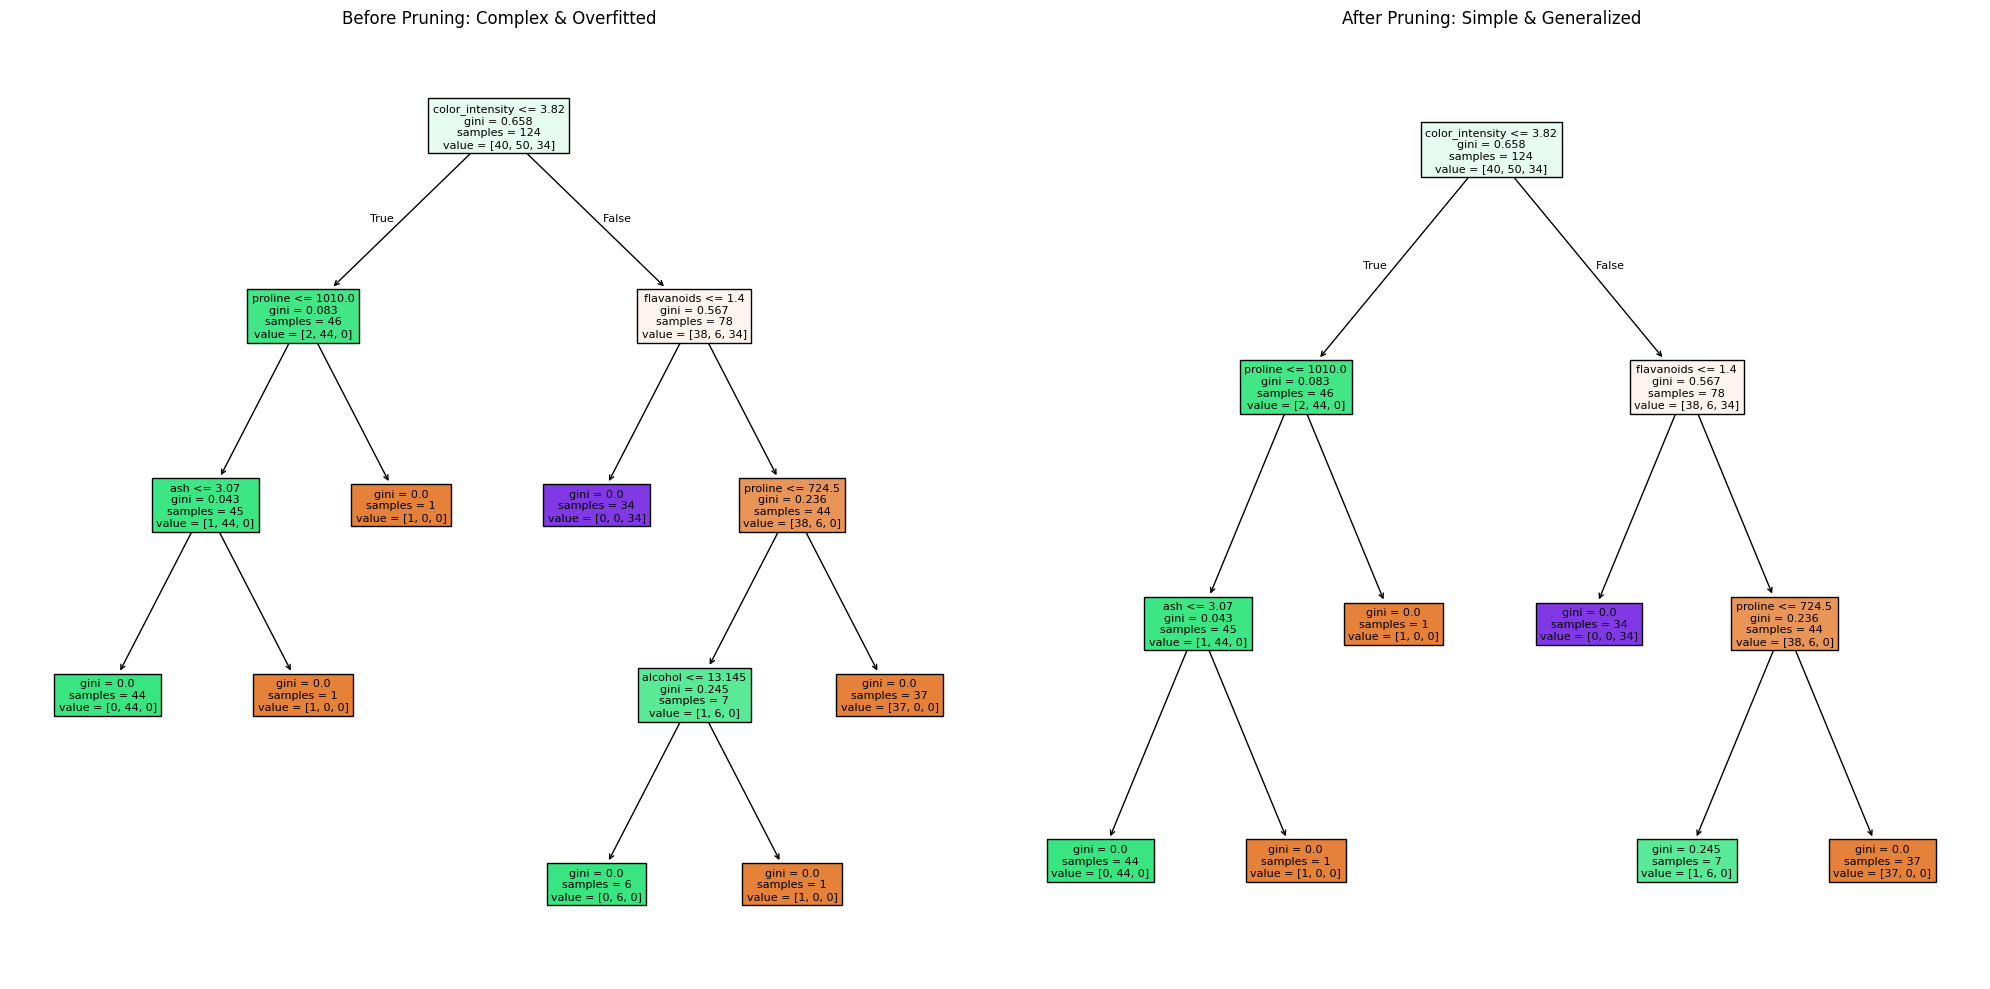

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load the dataset
data = load_wine()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Create an Unpruned Model (Overfitted)
# High depth allows it to "memorize" the training data
unpruned_clf = DecisionTreeClassifier(random_state=42)
unpruned_clf.fit(X_train, y_train)

# 3. Create a Pruned Model (Generalized)
# Pre-pruning: limiting depth to 3
pruned_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_clf.fit(X_train, y_train)


unpruned_train_acc = accuracy_score(y_train, unpruned_clf.predict(X_train))
unpruned_test_acc = accuracy_score(y_test, unpruned_clf.predict(X_test))

pruned_train_acc = accuracy_score(y_train, pruned_clf.predict(X_train))
pruned_test_acc = accuracy_score(y_test, pruned_clf.predict(X_test))

print(f"--- Unpruned Model ---")
print(f"Train Accuracy: {unpruned_train_acc:.2f} | Test Accuracy: {unpruned_test_acc:.2f}")

print(f"\n--- Pruned Model (max_depth=3) ---")
print(f"Train Accuracy: {pruned_train_acc:.2f} | Test Accuracy: {pruned_test_acc:.2f}")

# 4. Visualizing the Before and After
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Plot Unpruned
plot_tree(unpruned_clf, filled=True, feature_names=data.feature_names, ax=ax[0])
ax[0].set_title("Before Pruning: Complex & Overfitted")

# Plot Pruned
plot_tree(pruned_clf, filled=True, feature_names=data.feature_names, ax=ax[1])
ax[1].set_title("After Pruning: Simple & Generalized")

plt.tight_layout()
plt.show()

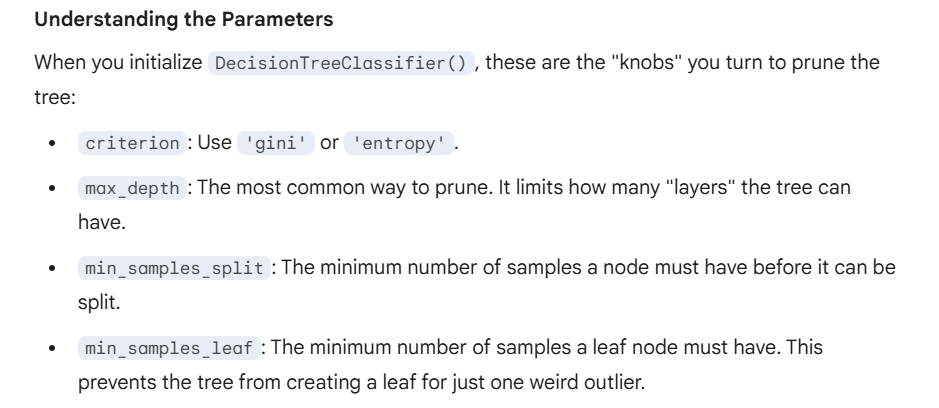

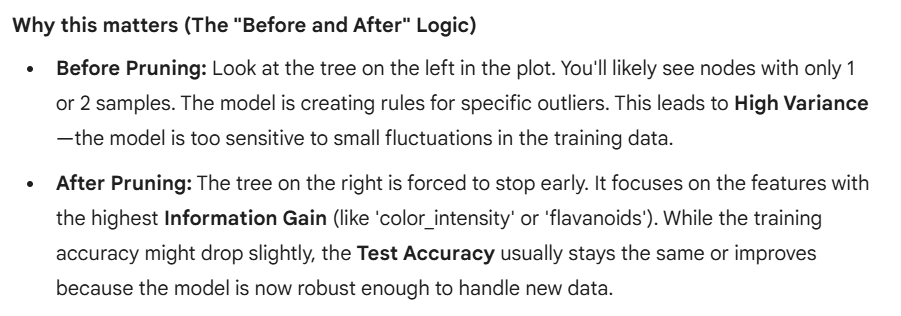